In [2]:
#imports
import cv2
import tifffile as tiff
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import csv

import os
from natsort import natsorted
import re
import argparse

from scipy.interpolate import splprep, splev

from skimage.morphology import medial_axis, skeletonize
from skimage import data
from skimage.util import invert
import skimage.graph

In [26]:
def make_skeleton(start_point, end_point, num_splines, img, min_worm_len=0):
    """
    Make an skeleton from binary image and start and end point
    Parameters:
    -----------
    start_point: tuple with x,y coordinates
    end_point: tuple with x,y coordinates
    min_worm_len: minimum worm length in pixels, if the found centerline is below it will be nan (default is 0)
    num_splines: number of splines you want to fit
    img: binary img from where the skeleton will be calculated
    min_worm_len: int, minimun length the worm should have. Default 0.
    """

    # check if image is empty,
    all_zeros = not np.any(img)

    if all_zeros == True:
        print("img is emtpy, no centerline should be calculated")
        K = np.full(num_splines, np.nan)
        x = np.full(num_splines, np.nan)
        y = np.full(num_splines, np.nan)
        x_new = np.full(num_splines, np.nan)
        y_new = np.full(num_splines, np.nan)
        u = np.nan
    #image is not empty, proceed
    else:
        #this defines the costs for the shortest path
        costs=cv2.distanceTransform(img, cv2.DIST_L2,3)
        cv2.normalize(costs, costs, 0, 255, cv2.NORM_MINMAX)
        costs=costs.max()-costs

        #to increase the value a lot of the pixels outside the worm contour (np.inf will not work! sometimes head and tail outside work contour)
        costs=np.where(costs>254.9, 255*100, costs)
        #actual skeleton based on route through array from skimage
        try:
            path, cost = skimage.graph.route_through_array(costs, start=start_point, end=end_point, fully_connected=False)
            x, y = np.asarray(list(zip(*path)), dtype=int)
            # pts=np.asarray(path, dtype=np.int)
            value_error = False
            # if coordinates from route_through_array are smaller than min_worm_len or num_splines, it is not a good centerline
            if len(x) < min_worm_len or len(x) < num_splines:
                # print('Knots are Nans in: '+str(i))
                K = np.full(num_splines, np.nan)
                x = np.full(num_splines, np.nan)
                y = np.full(num_splines, np.nan)
                x_new = np.full(num_splines, np.nan)
                y_new = np.full(num_splines, np.nan)
                u = np.nan
            # else, the path was good, fit a spline and find curvature
            else:
                ####
                ##SHOULD THIS PART HERE BE CONVERTED TO A FUNCTION?? (or some of it)
                # s is the smoothing condition should have around the size of points/2 (keep it low)
                # k is the degree of freedom for the polynom it fits, 5 is good
                # splprep calculates automatically the number of knots. One can see how many in tck.shape[1].
                # everytime splprep is run the number may differ
                tck, u = splprep([x, y], u=None, s=x.shape[0] / 2, per=0, k=5)
                u_new = np.linspace(u.min(), u.max(), num_splines)  # 1000)

                x_new, y_new = splev(u_new, tck, der=0)

                # this returns x'(s), y'(s)
                x_der, y_der = splev(u_new, tck, der=1)
                # to have y'(x):
                der = y_der / x_der

                # this returns x''(s), y''(s)
                x_der2, y_der2 = splev(u_new, tck, der=2)
                # to have y''(x), also called K for Curvature:
                # we need the following equation:
                # ref in: https://en.wikipedia.org/wiki/Curvature#In_terms_of_a_general_parametrization (1st equation)
                K = (x_der * y_der2 - y_der * x_der2) / np.sqrt(x_der ** 2 + y_der ** 2) ** 3

        except ValueError:
            print("ValueError detected, data will be np.nan")
            value_error = True
            K=np.full(num_splines, np.nan)
            x=np.full(num_splines, np.nan)
            y=np.full(num_splines, np.nan)
            x_new=np.full(num_splines, np.nan)
            y_new=np.full(num_splines, np.nan)
            u=np.nan


    return u, (x,y), (x_new, y_new), K

In [4]:
#img path
img_path = "/Volumes/scratch/neurobiology/zimmer/jalaja/behaviour/Autoscope/27-11-22/data/w8/2022-11-27_18-58_w8_Ch0/raw_stack_background_subtracted_mask.btf"



In [3]:
#path to hdf5
hdf5_path = "/Volumes/scratch/neurobiology/zimmer/jalaja/behaviour/Autoscope/27-11-22/data/w8/2022-11-27_18-58_w8_Ch0/raw_stackDLC_resnet50_Autoscope_recordingsFeb1shuffle1_1030000.h5"


In [6]:
df = pd.read_hdf(hdf5_path)

In [7]:
df

scorer    DLC_resnet50_Autoscope_recordingsFeb1shuffle1_1030000              \
bodyparts                                                  head               
coords                                                        x           y   
0                                                 822.955261     968.408325   
1                                                 811.712952     961.140015   
2                                                 790.536499     977.712646   
3                                                 772.815247     984.841492   
4                                                 764.447998     973.052307   
...                                                      ...            ...   
9564                                             1432.060791     941.151367   
9565                                             1432.988647     940.911011   
9566                                             1434.935913     942.096252   
9567                                             1438.950928     942.853882   
9568                                             1443.274780     943.357788   

scorer                                                    
bodyparts                   tail                          
coords    likelihood           x            y likelihood  
0           0.999927  580.745239  1066.167358   0.974286  
1           0.999932  596.137573  1065.448853   0.881969  
2           0.999982  608.815186  1060.395020   0.965580  
3           0.999978  614.137817  1054.676025   0.947757  
4           0.999022  625.333313  1049.397949   0.997270  
...              ...         ...          ...        ...  
9564        0.974247  922.002563   938.046570   0.994143  
9565        0.987557  972.915039  1153.411987   0.998240  
9566        0.977711  972.471924  1155.416504   0.999257  
9567        0.906378  970.585632  1153.611572   0.999306  
9568        0.981271  969.179993  1151.450928   0.999052  

[9569 rows x 6 columns]

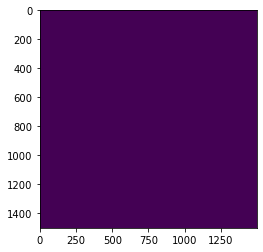

In [27]:
with tiff.TiffFile(img_path) as tif:
    for idx, page in enumerate(tif.pages):
        if idx<5669:continue
        img=page.asarray()
        plt.imshow(img)
        plt.show()
        break

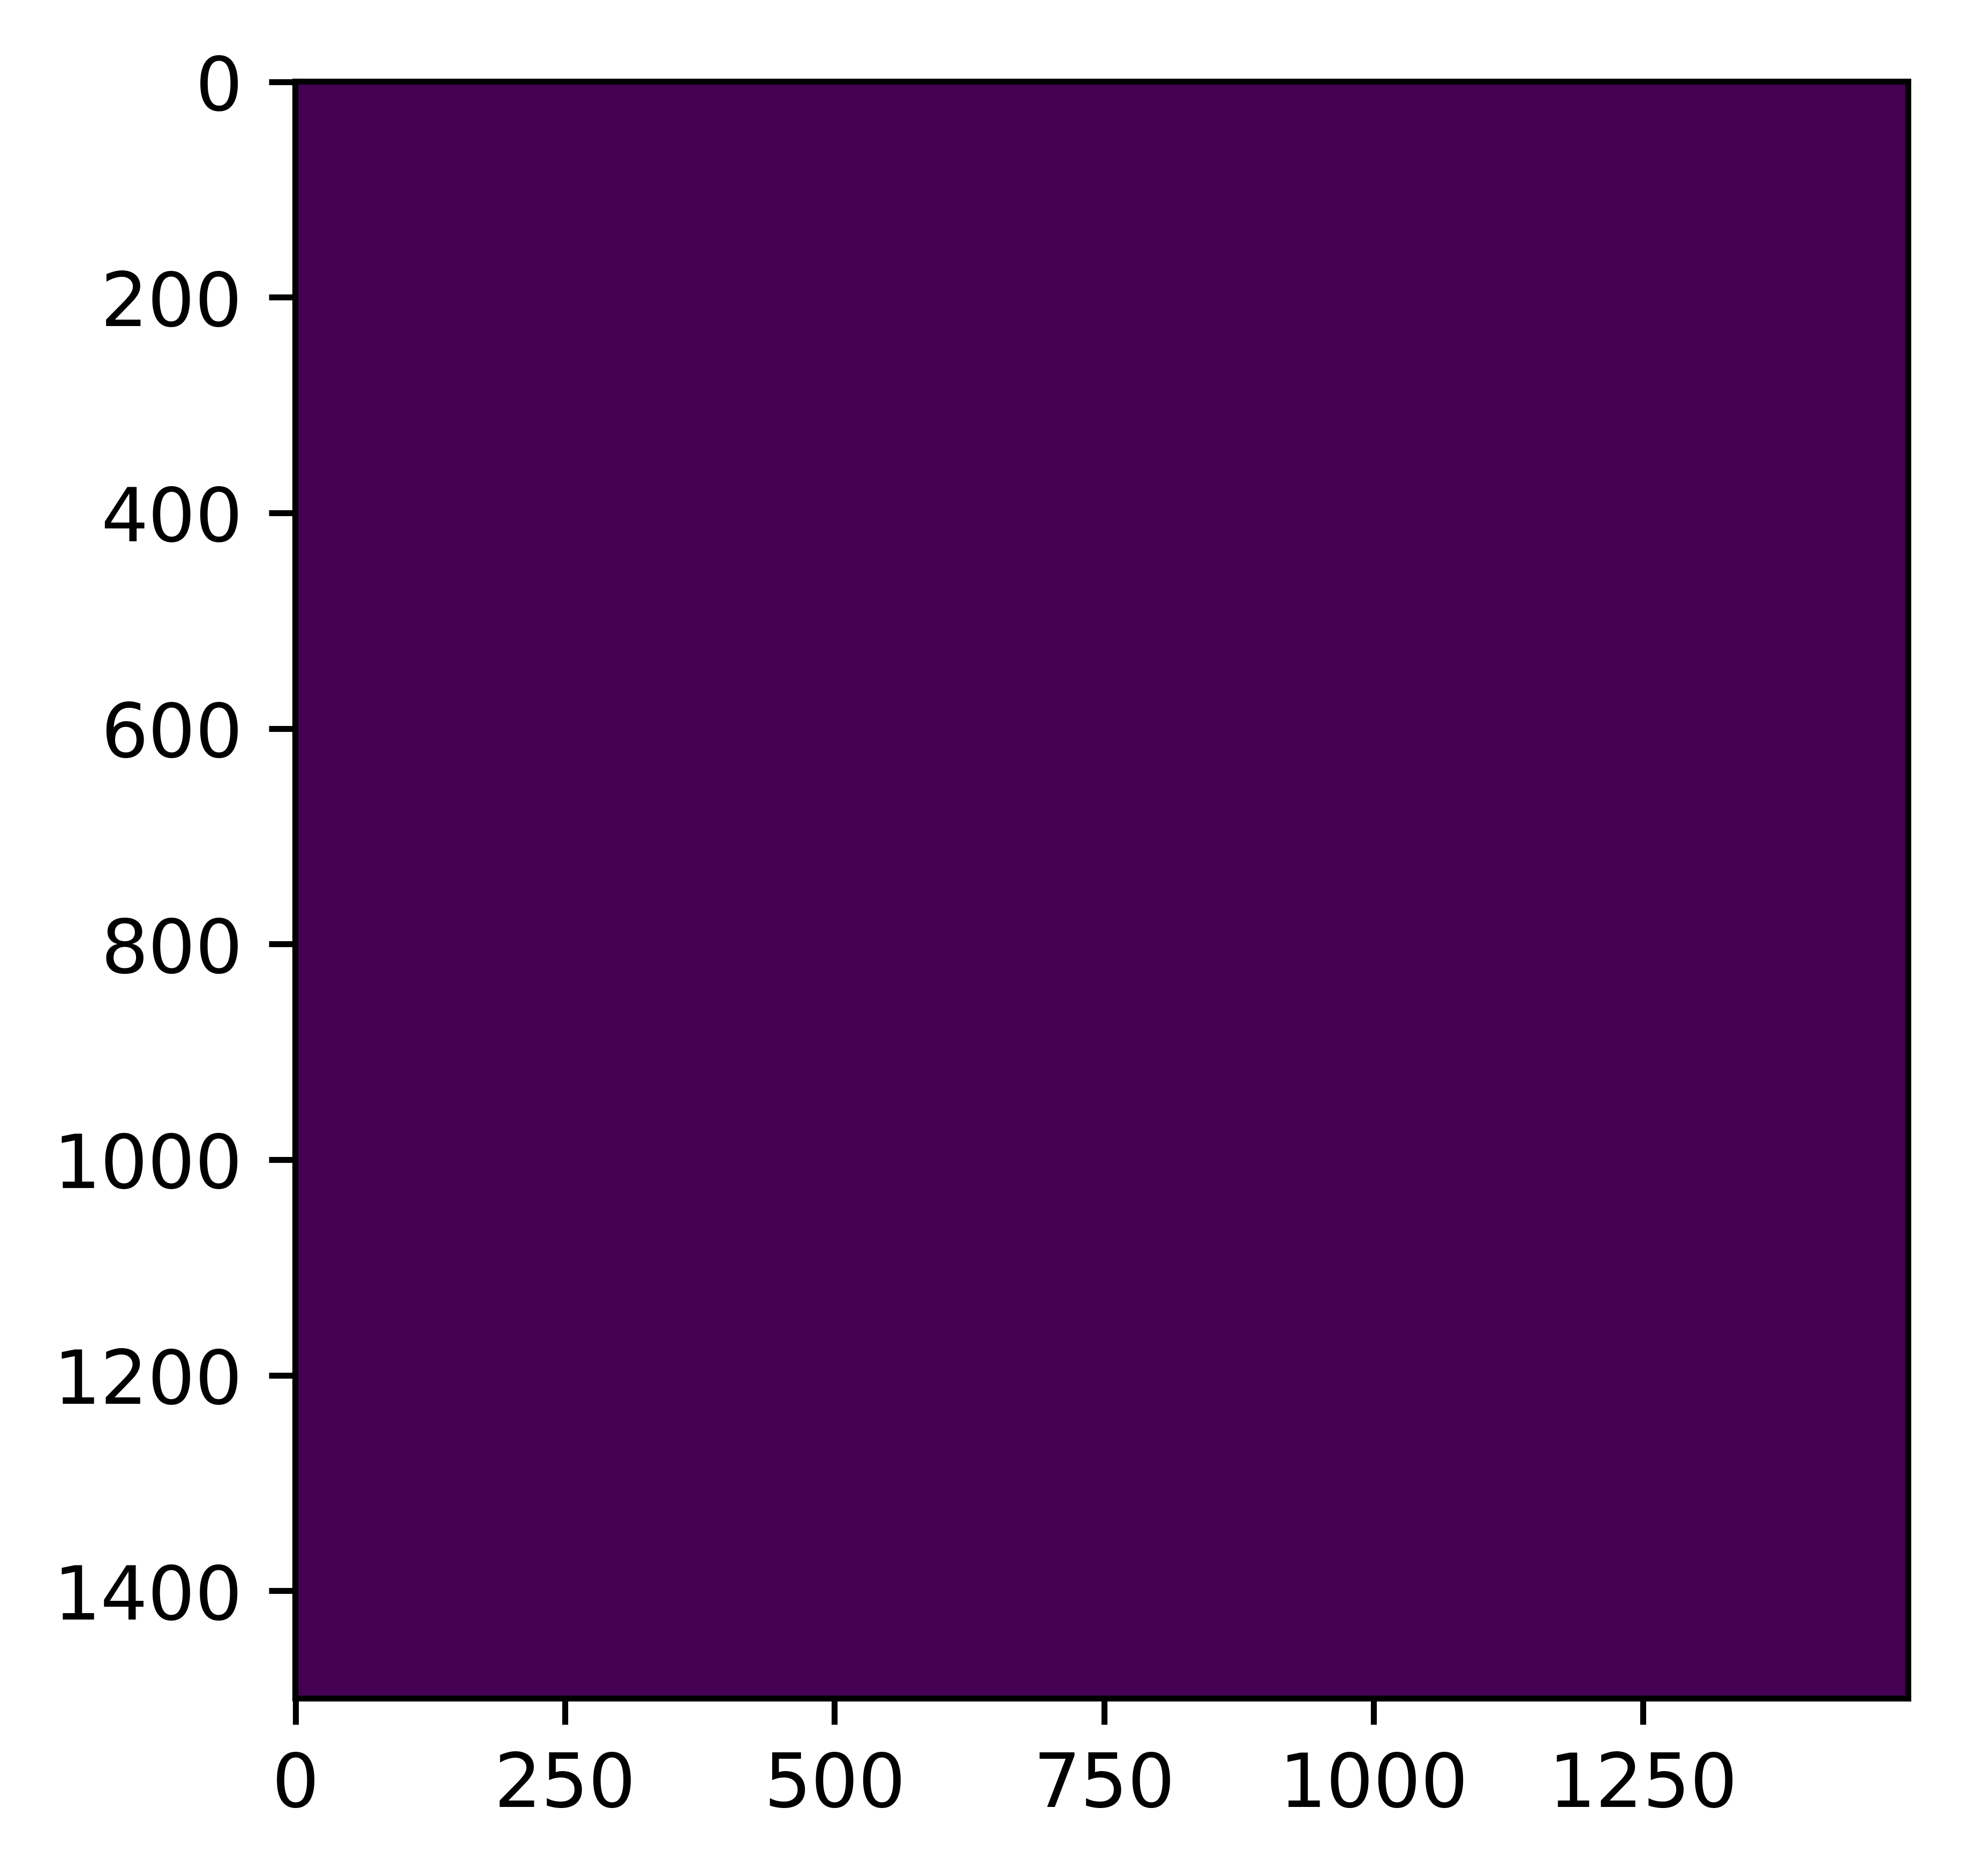

In [28]:
fig, ax = plt.subplots(dpi=1000)
ax.imshow(img)

In [29]:
u, (x,y), (x_new, y_new), K = make_skeleton((600,600), (500,500), num_splines=100, img=img, min_worm_len=0)

img is emtpy, no centerline should be calculated


In [30]:
all_zeros = not np.any(img)

In [31]:
all_zeros

True

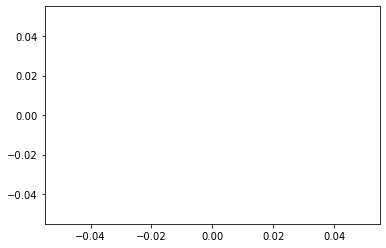

In [32]:
plt.plot(x_new,y_new)